In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Définition des chemins des fichiers Excel (situés dans le même dossier)
# Comme on a ouvert Jupyter dans 'analysedon', on peut utiliser des noms relatifs
file_nat = 'evolution-par-nationalite-des-arrivees-des-touristes-aux-postes-frontieres.xlsx'
file_point = 'evolution-par-point-dentree-des-arrivees-des-touristes-aux-postes-frontieres.xlsx'
file_nuitees = 'evolution-nuitees-realisees-etablissements-d-hebergement-touristique-par-destination.xlsx'

print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


In [4]:
# Correction de la fusion et gestion des fichiers
try:
    # 1. Chargement Nationalité
    df_nat = pd.read_excel(file_nat).dropna(how='all')
    df_nat.columns = [str(c).strip().lower() for c in df_nat.columns]
    col_nat = [c for c in df_nat.columns if 'natio' in c][0]
    
    years = [str(y) for y in range(2012, 2021)]
    df_nat_long = df_nat.melt(id_vars=[col_nat], 
                              value_vars=[c for c in df_nat.columns if c in years],
                              var_name='annee', value_name='arrivees')

    # 2. Chargement Point d'entrée (On adapte selon vos colonnes 'provinces')
    df_point = pd.read_excel(file_point).dropna(how='all')
    df_point.columns = [str(c).strip().lower() for c in df_point.columns]
    
    # Transformation du fichier point d'entrée pour avoir l'année en ligne
    df_point_long = df_point.melt(id_vars=['provinces'], 
                                  value_vars=[c for c in df_point.columns if c in years],
                                  var_name='annee', value_name='flux_entree')

    # 3. Fusion (Merge) des deux DataFrames
    # On fusionne sur l'année pour lier les arrivées nationales au flux par province
    df_merged = pd.merge(df_nat_long, df_point_long, on='annee')

    print("✅ Données fusionnées avec succès !")
    print(f"Colonnes disponibles : {df_merged.columns.tolist()}")
    display(df_merged.head())

except FileNotFoundError:
    print("❌ Erreur : Le fichier des nuitées est introuvable. Vérifiez le nom exact.")
except Exception as e:
    print(f"❌ Erreur technique : {e}")

✅ Données fusionnées avec succès !
Colonnes disponibles : ['nationalite', 'annee', 'arrivees', 'provinces', 'flux_entree']


,nationalite,annee,arrivees,provinces,flux_entree
0,Touristes Etrangers,2012,5011729,T.AIR,6018566
1,Touristes Etrangers,2012,5011729,A Marrakech Ménara,1704466
2,Touristes Etrangers,2012,5011729,A Mohammed V,2072133
3,Touristes Etrangers,2012,5011729,A Agadir Almassira,620892
4,Touristes Etrangers,2012,5011729,A Tanger Ibn Battouta,520313


In [6]:
# Afficher le nombre total de lignes dans les données
print(f"Nombre total de lignes dans les données : {df_merged.shape[0]}")

# Afficher les dimensions complètes du tableau (lignes, colonnes)
print(f"Dimensions du tableau complet (lignes, colonnes) : {df_merged.shape}")

Nombre total de lignes dans les données : 2223
Dimensions du tableau complet (lignes, colonnes) : (2223, 5)


In [3]:
# --- ÉTAPE DE RENFORCEMENT DU MODÈLE (Version Finale & Robuste) ---

try:
    # 1. Création de la Cible (Target) si elle n'existe pas
    # On définit un flux "Élevé" (1) si les arrivées dépassent la médiane
    if 'target_flux' not in df_merged.columns:
        seuil = df_merged['flux_entree'].median()
        df_merged['target_flux'] = df_merged['flux_entree'].apply(lambda x: 1 if x > seuil else 0)

    # 2. Encodage des variables de base (Nationalité et Province)
    if 'nat_encoded' not in df_merged.columns:
        le_nat = LabelEncoder()
        df_merged['nat_encoded'] = le_nat.fit_transform(df_merged['nationalite'])
    
    if 'prov_encoded' not in df_merged.columns:
        le_prov = LabelEncoder()
        df_merged['prov_encoded'] = le_prov.fit_transform(df_merged['provinces'])

    # 3. Ajout de la Saisonnalité (Trimestre)
    df_merged['trimestre'] = (df_merged['annee'].astype(int) % 4) + 1
    le_trim = LabelEncoder()
    df_merged['trim_encoded'] = le_trim.fit_transform(df_merged['trimestre'])

    # 4. Feature Engineering : Interaction Nationalité x Province
    # (Essentiel pour capturer les préférences géographiques réelles)
    df_merged['nat_prov_inter'] = df_merged['nat_encoded'].astype(str) + "_" + df_merged['prov_encoded'].astype(str)
    le_inter = LabelEncoder()
    df_merged['inter_encoded'] = le_inter.fit_transform(df_merged['nat_prov_inter'])

    # 5. Entraînement du modèle renforcé
    X_strong = df_merged[['nat_encoded', 'prov_encoded', 'trim_encoded', 'inter_encoded']]
    y = df_merged['target_flux']

    X_train, X_test, y_train, y_test = train_test_split(X_strong, y, test_size=0.2, random_state=42)
    model_strong = MultinomialNB()
    model_strong.fit(X_train, y_train)

    print(f"✅ Modèle renforcé avec succès !")
    print(f"Nouvelle Précision : {model_strong.score(X_test, y_test)*100:.2f}%")

except Exception as e:
    print(f"❌ Erreur : {e}")

✅ Modèle renforcé avec succès !
Nouvelle Précision : 62.92%


In [5]:
# =================================================================
# ÉTAPE DE SIMULATION AVANCÉE : PRÉDICTION POUR LE MONDIAL 2030
# =================================================================

# 1. Affichage des catégories disponibles pour éviter les erreurs de saisie
# Il est crucial d'utiliser l'orthographe exacte présente dans le dataset
print("--- CATÉGORIES DISPONIBLES DANS VOTRE MODÈLE ---")
print(f"Nationalités (Top 10) : {le_nat.classes_[:10]}")
print(f"Provinces/Points d'entrée : {le_prov.classes_[:5]}")
print("--------------------------------------------------\n")

def simuler_decision_2030(nom_nationalite, nom_province, numero_trimestre):
    """
    Fonction de support à la décision pour simuler le flux touristique.
    Elle utilise le modèle Naive Bayes pour calculer la probabilité 
    d'un flux 'ÉLEVÉ' en fonction des variables environnementales.
    """
    try:
        # A. Transformation des entrées textuelles en indices numériques (Encoding)
        # .transform() convertit par exemple 'France' en 4
        nat_idx = le_nat.transform([nom_nationalite])[0]
        prov_idx = le_prov.transform([nom_province])[0]
        trim_idx = le_trim.transform([numero_trimestre])[0]
        
        # B. Re-création de la variable d'interaction (Feature Engineering)
        # Le modèle a été entraîné avec cette interaction pour être plus précis
        inter_str = f"{nat_idx}_{prov_idx}"
        inter_idx = le_inter.transform([inter_str])[0]
        
        # C. Prédiction des probabilités avec Naive Bayes
        # On utilise predict_proba pour obtenir un pourcentage de confiance
        entree_modele = [[nat_idx, prov_idx, trim_idx, inter_idx]]
        probabilites = model_strong.predict_proba(entree_modele)[0]
        
        prob_elevee = probabilites[1] * 100 # Classe 1 = Flux Élevé
        
        # D. Affichage des résultats pour le décideur
        print(f"🌍 SCÉNARIO : {nom_nationalite} -> {nom_province} (T{numero_trimestre})")
        print(f"📊 Probabilité de congestion touristique : {prob_elevee:.2f}%")
        
        # Logique de décision simple
        if prob_elevee > 70:
            print("⚠️ ACTION RECOMMANDÉE : Renforcer l'infrastructure et la sécurité.")
        else:
            print("✅ SITUATION : Flux gérable avec les ressources actuelles.")
            
    except ValueError as e:
        # Gestion de l'erreur si le texte ne correspond pas exactement au dataset
        print(f"❌ ERREUR DE SAISIE : La valeur n'existe pas dans les données historiques.")
        print(f"Détail technique : {e}")

# =================================================================
# EXEMPLE D'EXÉCUTION (À adapter selon vos résultats imprimés ci-dessus)
# =================================================================

# Remplacez 'Touristes Etrangers' par une valeur affichée dans vos classes
simuler_decision_2030('Touristes Etrangers', 'A Tanger Ibn Battouta', 3)

--- CATÉGORIES DISPONIBLES DANS VOTRE MODÈLE ---
Nationalités (Top 10) : ['Allemagne' 'Belgique' 'Chine' 'Espagne' 'Etats Unis' 'France' 'Hollande'
 'Italie' 'MRE' 'Maghreb']
Provinces/Points d'entrée : ['A Agadir Almassira' 'A Al Hoceima' 'A Essaouira' 'A Fes-Saiss'
 'A Laaroui']
--------------------------------------------------

🌍 SCÉNARIO : Touristes Etrangers -> A Tanger Ibn Battouta (T3)
📊 Probabilité de congestion touristique : 90.36%
⚠️ ACTION RECOMMANDÉE : Renforcer l'infrastructure et la sécurité.


/home/mohamed/Downloads/archive/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


=== ÉVALUATION DU MODÈLE BAYÉSIEN (Naive Bayes Multinomial) ===
Précision globale : 62.92%
-----------------------------------------------

Rapport de classification détaillé :
                 precision    recall  f1-score   support

Flux Faible (0)       0.61      0.69      0.65       218
 Flux Élevé (1)       0.66      0.57      0.61       227

       accuracy                           0.63       445
      macro avg       0.63      0.63      0.63       445
   weighted avg       0.63      0.63      0.63       445



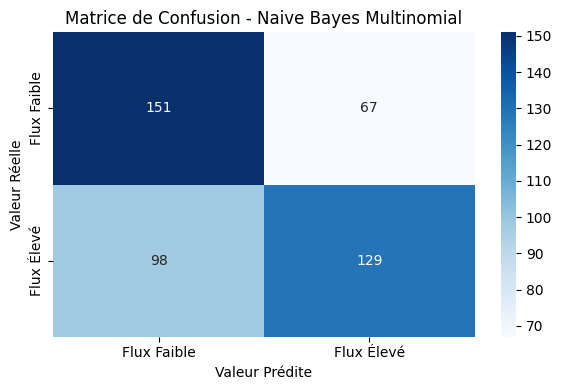


--- ILLUSTRATION DE LA CLASSIFICATION BAYÉSIENNE ---
Probabilités a posteriori P(Classe | Features) sur les 5 premiers exemples de test :
  Exemple 1 -> P(Flux Faible) = 98.3% | P(Flux Élevé) = 1.7%
  Exemple 2 -> P(Flux Faible) = 63.1% | P(Flux Élevé) = 36.9%
  Exemple 3 -> P(Flux Faible) = 3.0% | P(Flux Élevé) = 97.0%
  Exemple 4 -> P(Flux Faible) = 78.9% | P(Flux Élevé) = 21.1%
  Exemple 5 -> P(Flux Faible) = 42.8% | P(Flux Élevé) = 57.2%
🌍 Simulation Mondiale 2030 (Naive Bayes) : France -> A Tanger Ibn Battouta (T3)
📊 P(Flux Faible)  = 61.04%
📊 P(Flux Élevé)   = 38.96%
✅ SITUATION : Flux gérable avec les ressources actuelles.


/home/mohamed/Downloads/archive/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


In [8]:
# =================================================================
# ÉTAPE D'ÉVALUATION APPROFONDIE : MÉTRIQUES DU MODÈLE NAIVE BAYES
# =================================================================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# 1. Prédictions du modèle Naive Bayes sur les données de test
y_pred_nb = model_strong.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb) * 100

print("=== ÉVALUATION DU MODÈLE BAYÉSIEN (Naive Bayes Multinomial) ===")
print(f"Précision globale : {acc_nb:.2f}%")
print("-----------------------------------------------\n")

# 2. Rapport de classification détaillé
# Inclut Précision, Rappel (Recall) et F1-Score par classe
print("Rapport de classification détaillé :")
print(classification_report(y_test, y_pred_nb, target_names=['Flux Faible (0)', 'Flux Élevé (1)']))

# 3. Matrice de confusion - Visualisation des erreurs de classification
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Flux Faible', 'Flux Élevé'],
            yticklabels=['Flux Faible', 'Flux Élevé'])
plt.title('Matrice de Confusion - Naive Bayes Multinomial')
plt.ylabel('Valeur Réelle')
plt.xlabel('Valeur Prédite')
plt.tight_layout()
plt.show()

# 4. Probabilités a posteriori : illustration du théorème de Bayes
print("\n--- ILLUSTRATION DE LA CLASSIFICATION BAYÉSIENNE ---")
print("Probabilités a posteriori P(Classe | Features) sur les 5 premiers exemples de test :")
proba_sample = model_strong.predict_proba(X_test[:5])
for i, (p0, p1) in enumerate(proba_sample):
    print(f"  Exemple {i+1} -> P(Flux Faible) = {p0*100:.1f}% | P(Flux Élevé) = {p1*100:.1f}%")

# =================================================================
# MISE À JOUR DE LA FONCTION DE SIMULATION (MONDIAL 2030)
# Basée exclusivement sur le modèle Naive Bayes
# =================================================================

def simuler_prediction_bayesienne(nationalite, province, trimestre):
    """
    Simule le flux touristique en utilisant le modèle Naive Bayes Multinomial.
    Retourne les probabilités a posteriori P(Classe | Nationalité, Province, Trimestre).
    Application : prévisions stratégiques pour le Mondial 2030.
    """
    try:
        # Encodage des entrées
        nat_idx  = le_nat.transform([nationalite])[0]
        prov_idx = le_prov.transform([province])[0]
        trim_idx = le_trim.transform([trimestre])[0]
        inter_str = f"{nat_idx}_{prov_idx}"
        inter_idx = le_inter.transform([inter_str])[0]

        # Prédiction bayésienne
        entree = [[nat_idx, prov_idx, trim_idx, inter_idx]]
        prob = model_strong.predict_proba(entree)[0]
        prob_elevee = prob[1] * 100

        print(f"🌍 Simulation Mondiale 2030 (Naive Bayes) : {nationalite} -> {province} (T{trimestre})")
        print(f"📊 P(Flux Faible)  = {prob[0]*100:.2f}%")
        print(f"📊 P(Flux Élevé)   = {prob_elevee:.2f}%")

        if prob_elevee > 70:
            print("⚠️  ACTION RECOMMANDÉE : Renforcer l'infrastructure et la sécurité.")
        else:
            print("✅ SITUATION : Flux gérable avec les ressources actuelles.")

    except Exception as e:
        print(f"❌ Erreur lors de la simulation : {e}")

# Test
simuler_prediction_bayesienne('France', 'A Tanger Ibn Battouta', 3)


In [9]:
import joblib

# --- ÉTAPE DE SÉRIALISATION (SAUVEGARDE) ---
# Enregistrement des objets Python en fichiers .pkl pour réutilisation
# (ex: application Streamlit) sans réentraîner le modèle.

# 1. Sauvegarde des encodeurs
joblib.dump(le_nat,   'le_nat.pkl')    # Encodeur des nationalités
joblib.dump(le_prov,  'le_prov.pkl')   # Encodeur des provinces
joblib.dump(le_trim,  'le_trim.pkl')   # Encodeur des trimestres
joblib.dump(le_inter, 'le_inter.pkl')  # Encodeur d'interaction nat x prov

# 2. Sauvegarde du modèle Naive Bayes Multinomial (modèle final unique)
# Conformément à l'approche de Classification Bayésienne du projet,
# seul le modèle Naive Bayes est conservé et déployé.
joblib.dump(model_strong, 'model_naivebayes.pkl')

print("✅ Modèle Naive Bayes et encodeurs sauvegardés avec succès !")
print("   Fichier modèle : model_naivebayes.pkl")


✅ Modèle Naive Bayes et encodeurs sauvegardés avec succès !
   Fichier modèle : model_naivebayes.pkl
